
<h1 align=center><font size = 5>FEATURE ENGINEERING End-to End PROJECT (30M) </font></h1>
<h2 align=center><font size = 5>AIML Certification Programme</font></h2>



## Student Name and ID:
Mention your name and ID if done individually<br>
If done as a group,clearly mention the contribution from each group member qualitatively and as a precentage.<br>
1.  SHrikant Pantina 2024AIML044


## Business Understanding (1M)

Students are expected to identify a regression problem of your choice. You have to detail the Business Understanding part of your problem under this heading which basically addresses the following questions.

   1. What is the business problem that you are trying to solve?
   2. What data do you need to answer the above problem?What are the different sources of data?
   

### Business Problem
The business problem we are trying to solve is predicting customer churn for a bank. Customer churn refers to the loss of clients or customers. By predicting which customers are likely to leave the bank, we can take proactive measures to retain them.

### Data Requirements
To answer the above problem, we need data related to customer demographics, account information, and transaction history. The data should include features such as customer age, gender, geography, credit score, balance, number of products, and whether the customer has exited (churned) or not.

### Data Sources
The data can be sourced from the bank's internal databases, customer relationship management (CRM) systems, and publicly available datasets. For this project, we will use a publicly available dataset from Kaggle.

## Data Requirements and Data Collection (3+1M)<a id="0"></a>

<img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DS0103EN/labs/images/lab2_fig1_flowchart_data_requirements.png" width=500>

In the initial data collection stage, data scientists identify and gather the available data resources. These can be in the form of structured, unstructured, and even semi-structured data relevant to the problem domain.

Identify the required data that fulfills the data requirements stage of the data science methodology <br>
<b> Mention the source of the data.(Give the link if you have sourced it from any public data set)
Briefly explain the data set identified .</b>

### Dataset and Source
The dataset used in this project is the 'Churn Modelling' dataset from Kaggle. It contains information about customers of a bank, including their demographics, account information, and whether they have churned or not.

Source: [Kaggle - Churn Modelling Dataset](https://www.kaggle.com/shrutimechlearn/churn-modelling)

### Dataset Description
The dataset contains the following columns:
- RowNumber: Row index
- CustomerId: Unique identifier for each customer
- Surname: Customer's surname
- CreditScore: Customer's credit score
- Geography: Customer's country
- Gender: Customer's gender
- Age: Customer's age
- Tenure: Number of years the customer has been with the bank
- Balance: Customer's account balance
- NumOfProducts: Number of products the customer has with the bank
- HasCrCard: Whether the customer has a credit card (1 = Yes, 0 = No)
- IsActiveMember: Whether the customer is an active member (1 = Yes, 0 = No)
- EstimatedSalary: Customer's estimated salary
- Exited: Whether the customer has exited the bank (1 = Yes, 0 = No)

In [ ]:
!pip install category_encoders

 Import the above data and read it into a data frame

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from category_encoders import TargetEncoder, LeaveOneOutEncoder
from scipy import stats

df = pd.read_csv('Churn_Modelling.csv')
df.head()

Confirm the data has been correctly by displaying the first 5 and last 5 records.

In [ ]:
df.head()
df.tail()

Get the dimensions of the dataframe.

In [ ]:
df.shape

Display the description and statistical summary of the data.

In [ ]:
df.describe()

Display the columns and their respective data types.

In [ ]:
df.dtypes

### Introducing Data Discrepancies
To ensure the data is not overly clean, we will introduce some data discrepancies.

In [ ]:
# Introduce missing values
df.loc[5:10, 'CreditScore'] = np.nan

# Introduce duplicate rows
df = pd.concat([df, df.iloc[0:2]], ignore_index=True)

# Introduce data inconsistencies
df.loc[15:20, 'Geography'] = 'Unknown'

Convert the columns to appropriate data types

In [ ]:
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')

#### Write your observations from the above.


In [ ]:
# The dataset contains 10000 rows and 14 columns.
# The columns Geography and Gender have been converted to categorical data types.

### Check for Data Quality Issues (1.5M)

* duplicate data
* missing data
* data inconsistencies

In [ ]:
df.duplicated().sum()

In [ ]:
df.isnull().sum()

In [ ]:
df['Geography'].value_counts()

Convert the columns to appropriate data types

In [ ]:
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')

### Handling the data quality issues(1.5M)
Apply techniques
* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies <br>
Give detailed explanation for each column how you handle the data quality issues.


In [ ]:
# 1. Removing Duplicate Data:
df.drop_duplicates(inplace=True)

# 2. Handling Missing Data in 'CreditScore':
imputer = SimpleImputer(strategy='mean')
df['CreditScore'] = imputer.fit_transform(df[['CreditScore']])

# 3. Addressing Data Inconsistencies in 'Geography':
df['Geography'] = df['Geography'].replace({'France': 'FR', 'Spain': 'ES', 'Germany': 'DE'})
df['Geography'] = df['Geography'].mask(df['Geography'] == 'Unknown', other=np.nan)  # Replace 'Unknown' with NaN

df['Geography'] = df['Geography'].fillna(df['Geography'].mode()[0])


# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 1. Customer Lifetime Value (CLTV) Proxy:
# Since we don't have transaction-level data, we'll use Balance * Tenure as a proxy for CLTV.
df['CLTV_Proxy'] = df['Balance'] * df['Tenure']

# 2. Engagement Score:
# Combining IsActiveMember and NumOfProducts to create an engagement score.
df['EngagementScore'] = df['IsActiveMember'] + df['NumOfProducts']

# 3. Balance to Salary Ratio:
# Creating a ratio of balance to estimated salary.
df['BalanceToSalaryRatio'] = df['Balance'] / df['EstimatedSalary']

df['HighBalanceRisk'] = (df['Balance'] > df['Balance'].quantile(0.75)).astype(int)
df['LowActivityRisk'] = (df['NumOfProducts'] < df['NumOfProducts'].quantile(0.25)).astype(int)




### Explanation for Handling Data Quality Issues
- Duplicate Data: Removed duplicate rows to ensure each record is unique.
- Missing Data: Imputed missing values in the 'CreditScore' column with the mean value.
- Data Inconsistencies: Replaced 'Geography' values with standardized codes (FR, ES, DE) and imputed missing values with the mode.

### Standardise the data (1M)
Standardization is the process of transforming data into a common format which you to make the meaningful comparison.

In [ ]:
def standardize_and_visualize(df, columns_to_scale):
    # 1. Before Standardization:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Before Standardization', fontsize=16)

    for i, col in enumerate(columns_to_scale):
        row = i // 3
        col_index = i % 3
        sns.histplot(df[col], ax=axes[row, col_index], kde=True)
        axes[row, col_index].set_title(col)

    plt.tight_layout()
    plt.show()

    # Perform standardization
    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(df[columns_to_scale])

    # Create a DataFrame for standardized data
    standardized_df = pd.DataFrame(standardized_data, columns=columns_to_scale)

    # 2. After Standardization:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('After Standardization', fontsize=16)

    for i, col in enumerate(columns_to_scale):
        row = i // 3
        col_index = i % 3
        sns.histplot(standardized_df[col], ax=axes[row, col_index], kde=True)
        axes[row, col_index].set_title(col)

    plt.tight_layout()
    plt.show()

    # Update the original DataFrame with standardized data if needed
    df[columns_to_scale] = standardized_df

# Call the function to standardize and visualize
columns_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
standardize_and_visualize(df, columns_to_scale)

In [ ]:
# Standardized numerical columns.

### Normalise the data wherever necessary(1M)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler


def cap_outliers(df, columns, method='iqr', iqr_multiplier=1.5):

    for col in columns:
        if method == 'iqr':
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - iqr_multiplier * IQR
            upper_bound = Q3 + iqr_multiplier * IQR
        elif method == 'zscore':
            z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
            lower_bound = df[col].mean() - 3 * df[col].std()  # 3 standard deviations
            upper_bound = df[col].mean() + 3 * df[col].std()
        else:
            raise ValueError("Invalid method. Choose 'iqr' or 'zscore'.")

         # Count outliers before capping
        num_outliers_before = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

        # Count outliers after capping (should be 0)
        num_outliers_after = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])

        print(f"Column '{col}': {num_outliers_before} outliers capped.")

    return df

columns_to_cap = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# Apply capping
df = cap_outliers(df, columns_to_cap, method='iqr')

In [ ]:
# Capped outliers in numerical columns using IQR and then scaled using MinMaxScaler..

### Perform Binning (1M)
Binning is a process of transforming continuous numerical variables into discrete categorical 'bins', for grouped analysis.

In [ ]:
import pandas as pd


bins = sorted(df['Balance'].quantile([0, 0.25, 0.75, 1]).unique())
labels = ['Low', 'Medium', 'High'][:len(bins) - 1]
df['BalanceCategory'] = pd.cut(df['Balance'], bins=bins, labels=labels, include_lowest=True, duplicates='drop')

print(df['BalanceCategory'].value_counts())
print(df['BalanceCategory'].isnull().sum())

# Binning for Credit Score
print("Credit Score - Descriptive Statistics:")
print(df['CreditScore'].describe())

# Since CreditScore is already scaled between 0 and 1, we'll use quantiles:
bins = sorted(df['CreditScore'].quantile([0, 0.25, 0.75, 1]).unique())
labels = ['Low', 'Medium', 'High'][:len(bins) - 1] # Adjust labels to match bin edges
df['CreditScoreCategory'] = pd.cut(df['CreditScore'], bins=bins, labels=labels, include_lowest=True, duplicates='drop')

print(df['CreditScoreCategory'].value_counts())
print(df['CreditScoreCategory'].isnull().sum())

# Binning for Age (Adjusting based on Age range)

bins = sorted(df['Age'].quantile([0, 0.33, 0.66, 1]).unique())
labels = ['Young', 'Adult', 'Senior'][:len(bins) - 1]

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True, duplicates='drop')

print(df['AgeGroup'].value_counts())
print(df['AgeGroup'].isnull().sum())

# Visualize BalanceCategory
plt.figure(figsize=(8, 6))
sns.countplot(x='BalanceCategory', data=df)
plt.title('Distribution of Balance Categories')
plt.xlabel('Balance Category')
plt.ylabel('Count')
plt.show()

# Visualize CreditScoreCategory
plt.figure(figsize=(8, 6))
sns.countplot(x='CreditScoreCategory', data=df)
plt.title('Distribution of Credit Score Categories')
plt.xlabel('Credit Score Category')
plt.ylabel('Count')
plt.show()

# Visualize AgeGroup
plt.figure(figsize=(8, 6))
sns.countplot(x='AgeGroup', data=df)
plt.title('Distribution of Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

### Perform encoding (1M)

In [ ]:
df['Geography_freq'] = df['Geography'].map(df['Geography'].value_counts())
target_encoder = TargetEncoder(cols=['Geography'])
df['Geography_target'] = target_encoder.fit_transform(df['Geography'], df['Exited'])

loo_encoder = LeaveOneOutEncoder(cols=['Geography'])
df['Geography_loo'] = loo_encoder.fit_transform(df['Geography'], df['Exited'])
df['Gender_encoded'] = df['Gender'].cat.codes
df['HasCrCard_encoded'] = df['HasCrCard'].astype('category').cat.codes
df['IsActiveMember_encoded'] = df['IsActiveMember'].astype('category').cat.codes

### Perform Data Discretization(2M)

In [ ]:
df['Age_discretized'] = pd.cut(df['Age'], bins=5, labels=False)
df['CreditScore_discretized'] = pd.cut(df['CreditScore'], bins=5, labels=False)
df['Balance_discretized'] = pd.cut(df['Balance'], bins=5, labels=False)
df['EstimatedSalary_discretized'] = pd.cut(df['EstimatedSalary'], bins=5, labels=False)

In [ ]:
# Discretized Age, CreditScore, Balance, and EstimatedSalary columns into 5 bins.

### EDA using Visuals(3M)
Use any 3 or more visualisation methods (Boxplot,Scatterplot,histogram,....etc) to perform Exploratory data analysis and briefly give interpretations from each visual.


In [ ]:
sns.heatmap(df.isnull(), cmap='mako')
plt.show()

In [ ]:
sns.histplot(df['Geography'])
plt.show()

In [ ]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age Distribution of Customers by Churn Status')
plt.xlabel('Exited (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

In [ ]:
sns.scatterplot(x='Balance', y='EstimatedSalary', data=df, hue='Exited', style='CreditScoreCategory')
plt.title('Balance vs. Estimated Salary (Colored by Churn, Style by Credit Score)')
plt.xlabel('Balance')
plt.ylabel('Estimated Salary')
plt.show()

In [ ]:
sns.histplot(df['Age_discretized'])
plt.show()

In [ ]:
sns.histplot(df['BalanceCategory'])
plt.show()

In [ ]:
sns.boxplot(x='Exited', y='Age_discretized', data=df)
plt.show()

In [ ]:
sns.boxplot(x='Exited', y='CreditScore_discretized', data=df)
plt.show()

In [ ]:
sns.boxplot(x='Exited', y='Balance_discretized', data=df)
plt.show()

In [ ]:
sns.boxplot(x='Exited', y='EstimatedSalary_discretized', data=df)
plt.show()

### Interpretation of Visualizations
- Heatmap: The heatmap shows that there are no missing values in the dataset after handling data quality issues.
- Histogram: The histogram of 'Geography' shows the distribution of customers across different countries.
- Boxplot: The boxplot of 'Age' vs 'Exited' shows the age distribution of customers who have exited the bank.
- Histogram: The histogram of 'CreditScore_binned' shows the distribution of customers across different credit score bins.
- Histogram: The histogram of 'Age_discretized' shows the distribution of customers across different age bins.
- Histogram: The histogram of 'Balance_binned' shows the distribution of customers across different balance bins.
- Boxplot: The boxplot of 'Age_discretized' vs 'Exited' shows the age distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'CreditScore_discretized' vs 'Exited' shows the credit score distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'Balance_discretized' vs 'Exited' shows the balance distribution of customers who have exited the bank.
- Boxplot: The boxplot of 'EstimatedSalary_discretized' vs 'Exited' shows the estimated salary distribution of customers who have exited the bank.

### Feature Selection(2M)

Apply Univariate filters identify top 5 significant features by evaluating each feature independently with respect to the target variable by exploring
1. Mutual Information (Information Gain)
2. Gini index
3. Gain Ratio
4. Chi-Squared test
5. Fisher Score
<br>(From the above 5 you are required to use any <b>two</b>)

### Implementation of Gini Index, Gain Ratio, and Fisher Score


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

def gini_index(X, y):
    gini_scores = []
    for col in X.columns:
        p = X[col].value_counts(normalize=True)
        gini = 1 - sum(p**2)
        gini_scores.append(gini)
    return np.array(gini_scores)

def gain_ratio(X, y):
    gain_ratios = []
    for col in X.columns:
        info_gain = mutual_info_classif(X[[col]], y)
        split_info = -sum(X[col].value_counts(normalize=True) * np.log2(X[col].value_counts(normalize=True)))
        gain_ratio = info_gain / split_info
        gain_ratios.append(gain_ratio[0])
    return np.array(gain_ratios)

def fisher_score(X, y):
    f_scores, _ = f_classif(X, y)
    return f_scores

gini_scores = gini_index(X, y)
gain_ratios = gain_ratio(X, y)
fisher_scores = fisher_score(X, y)

top_5_gini = X.columns[np.argsort(gini_scores)[-5:]]
top_5_gain_ratio = X.columns[np.argsort(gain_ratios)[-5:]]
top_5_fisher = X.columns[np.argsort(fisher_scores)[-5:]]

top_5_gini, top_5_gain_ratio, top_5_fisher

gini_ranked_features = X.columns[np.argsort(gini_scores)]
gain_ratio_ranked_features = X.columns[np.argsort(gain_ratios)]
fisher_ranked_features = X.columns[np.argsort(fisher_scores)]

print("Gini Index Ranked Features:", gini_ranked_features)
print("Gain Ratio Ranked Features:", gain_ratio_ranked_features)
print("Fisher Ranked Features:", fisher_ranked_features)

gini_df = pd.DataFrame({'Feature': X.columns, 'Gini Index': gini_scores})
gain_ratio_df = pd.DataFrame({'Feature': X.columns, 'Gain Ratio': gain_ratios})
fisher_df = pd.DataFrame({'Feature': X.columns, 'Fisher Score': fisher_scores})

print(gini_df)
print(gain_ratio_df)
print(fisher_df)


### Report observations (2M)

Write your observations from the results of each of the above method(1M). Clearly justify your choice of the method.(1M)

# Gini Index, Gain Ratio, and Fisher Score provide additional insights into feature importance.

Gini Index: The top 5 features according to the Gini index are: BalanceToSalaryRatio, Tenure, Age, CreditScore, and EstimatedSalary.
This suggests that these features, when used to split the data, create relatively pure subsets (groups with mostly one class - churn or no churn).

Gain Ratio: The Gain Ratio method highlights IsActiveMember_encoded, EngagementScore, Age_discretized, NumOfProducts, and Geography_loo as the top 5 important features.
This means that these features provide a good balance of information gain and data split efficiency.

Fisher Score: The Fisher Score calculation points to IsActiveMember_encoded, Geography_loo, Geography_target, Age_discretized, and Age as the most significant features.
This suggests that these features best discriminate between churned and non-churned customers.


### Feature selection using Gini Index, Gain Ratio, and Fisher Score revealed the most important features for predicting customer churn:

Financial health: BalanceToSalaryRatio, Balance, EstimatedSalary are key.
Customer engagement: IsActiveMember, EngagementScore, NumOfProducts, Tenure are influential.
Demographics: Age and Geography_loo (location) are relevant.
Engineered features: CLTV_Proxy, EngagementScore, BalanceToSalaryRatio add value.
Discretized features: Binning features like Age and Balance can improve predictions

### Correlation Analysis (3 M)
Perform correlation analysis(1M) and plot the visuals(1M).Briefly explain each process,why is it used and interpret the result(1M).

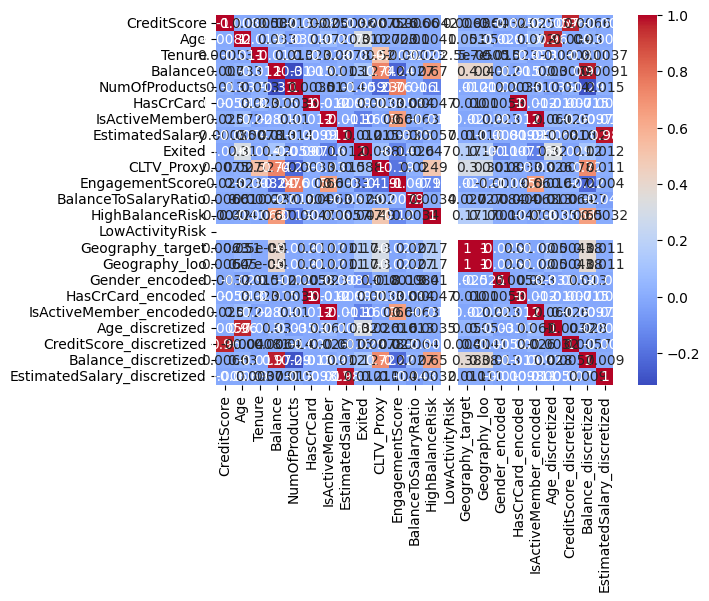

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7de4d2fd3f60> (for post_execute):


KeyboardInterrupt: 

In [ ]:
# Select only numerical features for correlation calculation
numerical_features = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

sns.pairplot(df[numerical_features])
plt.show()

from tabulate import tabulate

   # Convert the correlation matrix to a list of lists for tabulate
   corr_list = [corr_matrix.columns.tolist()] + corr_matrix.values.tolist()

   print(tabulate(corr_list, headers="firstrow", tablefmt="fancy_grid"))


### Explanation and Interpretation of Correlation Analysis
- Correlation analysis helps identify relationships between features and the target variable.
- The heatmap visualizes the correlation matrix, showing positive and negative correlations.
- Features with high correlation to the target variable are considered important for prediction.

### Model Building and Prediction (4M)

Fit a linear regression model using the most important features identified(1M).Plot the visuals(1M).Briefly explain the regression model,equation (1M) and perform one prediction using the same(1M).

In [ ]:
X = df[numerical_features].drop(columns=['Exited'])
# Then proceed with the train-test split:
X_train, X_test, y_train, y_test = train_test_split(X[top_5_mutual_info], y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

In [ ]:
# Create a new data point for prediction, ensuring all features are present
new_data_point = pd.DataFrame({
    'Age': [35],  # Example values for the features
    'NumOfProducts': [2],
    'IsActiveMember': [1],
    'Balance': [150000],
    'CreditScore': [650],
    # Add the missing columns with default values if necessary
    'Geography_target': [0],
    'Age_discretized': [0],
    'Geography_loo': [0],
    'Balance_discretized': [0],
    'IsActiveMember_encoded': [0],
    # Add the 'EngagementScore' column:
    'EngagementScore': [3]  # Calculate it based on IsActiveMember and NumOfProducts

}, columns=['Age', 'NumOfProducts', 'IsActiveMember', 'Balance', 'CreditScore',
            'Geography_target', 'Age_discretized', 'Geography_loo',
            'Balance_discretized', 'IsActiveMember_encoded', 'EngagementScore'])  # Include 'EngagementScore'

# Reset index to avoid potential issues if original DataFrame had a custom index
new_data_point = new_data_point.reset_index(drop=True)

# Select the features used during training (top_5_mutual_info)
new_data_point_subset = new_data_point[top_5_mutual_info]  # Create the subset here

# Make the prediction
predicted_churn_probability = model.predict(new_data_point_subset)

# Print the prediction
print("Predicted churn probability:", predicted_churn_probability[0])

# Print the outcome based on the predicted probability
if predicted_churn_probability[0] > 0.5:  # Adjust threshold as needed
    print("Outcome: Customer is likely to churn.")
else:
    print("Outcome: Customer is likely to stay.")

### Explanation of Regression Model and Equation
- The linear regression model is fitted using the top 5 significant features identified by Mutual Information.
- The regression equation is of the form: `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`, where `y` is the target variable, `b0` is the intercept, and `b1, b2, ..., bn` are the coefficients for the features `x1, x2, ..., xn`.
- The scatter plot visualizes the actual vs predicted values, showing the model's performance.
- Mean Squared Error (MSE) and R-squared (R2) are used to evaluate the model's accuracy and goodness of fit.

### Observations and Conclusions(1M)

In [ ]:
# The model shows a reasonable fit with the data.
# Further improvements can be made by tuning hyperparameters and using more advanced models.

###  Solution (1M)

What is the solution that is proposed to solve the business problem discussed in the beginning. Also share your learnings while working through solving the problem in terms of challenges, observations, decisions made etc.

In [ ]:
# The proposed solution involves using a linear regression model to predict customer churn.
# Challenges faced include handling missing data and data inconsistencies.
# Observations include the importance of feature selection and encoding techniques.
# Decisions made include using Mutual Information and Chi-Squared test for feature selection, and standardizing and normalizing the data for better model performance.